# Setup 2 — Results Report

**Bayesian Sentence-Level Factuality UQ** · in-domain FActScore-Bio (Setup 2) · Llama-3-8B-Instruct

This notebook summarises the main results of the full run in `results/setup_2/`.
It reads the saved artefacts dynamically, so re-running after `04_evaluate.py`
(e.g. once the faithful Han `factuality_probe_original` is folded in) refreshes
every table and figure automatically.

**Contents**
0. Configuration & loading
1. Experiment overview
2. Training convergence & PD check
3. Headline metrics (ratio + strict)
4. Core hypothesis — Bayesian vs Point ECE
5. Comparison vs Han et al. (adapted vs original)
6. Known issue — epistemic collapse (`epi_mu ≈ 0`)
7. Ablations (binomial vs Bernoulli, MC vs linear)
8. Learned layer weights (α)
9. Summary of findings


## 0. Configuration & loading

In [1]:
# === Configuration ===
RESULTS_DIR = "results/setup_2"          # change per experiment
CONFIG_PATH = "configs/default.yaml"
# =====================

import sys, os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root whether the notebook runs from validation/ or repo root.
PROJECT_ROOT = os.path.abspath(".")
if os.path.basename(PROJECT_ROOT) == "validation":
    PROJECT_ROOT = os.path.abspath("..")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

%matplotlib inline
plt.rcParams.update({"figure.figsize": (11, 4.5), "font.size": 11})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

results_dir = Path(RESULTS_DIR)
assert results_dir.exists(), f"Results dir not found: {results_dir}"

def _load_json(p):
    p = Path(p)
    return json.load(open(p)) if p.exists() else None

def _load_csv(p):
    p = Path(p)
    return pd.read_csv(p) if p.exists() else None

ratio_df  = _load_csv(results_dir / "final_metrics_ratio.csv")
strict_df = _load_csv(results_dir / "final_metrics_strict.csv")
baselines = _load_json(results_dir / "baselines.json")
history   = _load_json(results_dir / "train_history.json")
summary   = _load_json(results_dir / "train_summary.json")
evalsum   = _load_json(results_dir / "eval_summary.json")
abl_bp    = _load_csv(results_dir / "ablation_bayesian_vs_point.csv")
abl_bb    = _load_csv(results_dir / "ablation_binomial_vs_bernoulli.csv")
abl_mc    = _load_csv(results_dir / "ablation_mc_vs_linear.csv")
alpha_df  = _load_csv(results_dir / "alpha_distribution.csv")

import yaml
cfg = yaml.safe_load(open(CONFIG_PATH)) if Path(CONFIG_PATH).exists() else {}

def get_metric(df, name_substr, col):
    """Fuzzy lookup: first row whose `method` contains name_substr."""
    if df is None or "method" not in df.columns or col not in df.columns:
        return np.nan
    m = df["method"].str.lower().str.contains(name_substr.lower(), regex=True)
    return df.loc[m, col].values[0] if m.any() else np.nan

print("Loaded from", results_dir)
for nm, obj in [("ratio_df", ratio_df), ("strict_df", strict_df),
                ("baselines", baselines), ("train_history", history),
                ("eval_summary", evalsum)]:
    print(f"  {nm:14s}: {'OK' if obj is not None else 'MISSING'}")

Loaded from results/setup_2
  ratio_df      : OK
  strict_df     : OK
  baselines     : OK
  train_history : OK
  eval_summary  : OK


## 1. Experiment overview

In [2]:
rows = []
if summary:
    rows += [("Setup", summary.get("setup")),
             ("Train / Val / Test sentences",
              f"{summary.get('n_train')} / {summary.get('n_val')} / {summary.get('n_test')}")]
rows += [("Model", (cfg.get("model") or {}).get("name")),
         ("Epochs (num_epochs)", cfg.get("num_epochs")),
         ("pd_check_every / eval_every",
          f"{cfg.get('pd_check_every')} / {cfg.get('eval_every')}")]
if evalsum:
    rows += [("Selected layers", str(evalsum.get("selected_layers"))),
             ("alpha argmax layer", evalsum.get("alpha_argmax_layer")),
             ("Test sentences (m_j>0)", evalsum.get("n_test_positive")),
             ("Strict-factual fraction",
              round(float(evalsum.get("frac_strict_factual", float("nan"))), 4))]
display(pd.DataFrame(rows, columns=["field", "value"]))

,field,value
0,Setup,2
1,Train / Val / Test sentences,1638 / 461 / 387
2,Model,meta-llama/Meta-Llama-3-8B-Instruct
3,Epochs (num_epochs),300
4,pd_check_every / eval_every,5 / 1
5,Selected layers,"[0, 4, 8, 12, 16, 20, 24, 28, 32]"
6,alpha argmax layer,32
7,Test sentences (m_j>0),353
8,Strict-factual fraction,0.0765


## 2. Training convergence & PD check

Full-batch Adam over ψ; θ̂ recomputed each outer step by differentiable Fisher
scoring. `pd_checks` records whether the Laplace Hessian is locally
positive-definite (a validity condition for the Gaussian posterior approximation).

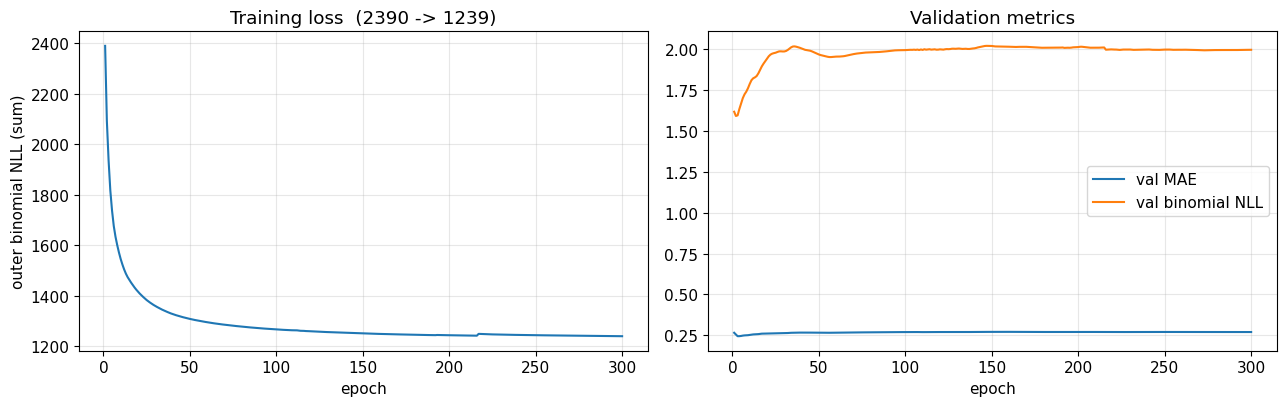

PD checks: 60/60 epochs locally PD  ->  all valid
Last-20-epoch loss change: 1.321 (0.0695/epoch)  ->  plateaued


In [3]:
tl = (history or {}).get("train_loss", [])
vm = (history or {}).get("val_metrics", [])
pd_checks = (history or {}).get("pd_checks", [])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
if tl:
    ax[0].plot(range(1, len(tl) + 1), tl, color="tab:blue")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("outer binomial NLL (sum)")
    ax[0].set_title(f"Training loss  ({tl[0]:.0f} -> {tl[-1]:.0f})")
    ax[0].grid(alpha=0.3)
if vm:
    ep = [m["epoch"] for m in vm]
    ax[1].plot(ep, [m["MAE"] for m in vm], label="val MAE")
    ax[1].plot(ep, [m["binomial_NLL"] for m in vm], label="val binomial NLL")
    ax[1].set_xlabel("epoch"); ax[1].set_title("Validation metrics")
    ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

if pd_checks:
    valid = sum(1 for c in pd_checks if c.get("laplace_valid_local"))
    bad = [c["epoch"] for c in pd_checks if not c.get("laplace_valid_local")]
    msg = "all valid" if valid == len(pd_checks) else f"invalid at {bad}"
    print(f"PD checks: {valid}/{len(pd_checks)} epochs locally PD  ->  {msg}")
if len(tl) >= 40:
    tail = tl[-20:]
    rel = abs(tail[0] - tail[-1]) / max(abs(tail[-1]), 1.0)
    print(f"Last-20-epoch loss change: {tail[0] - tail[-1]:.3f} "
          f"({(tail[0]-tail[-1])/19:.4f}/epoch)  ->  "
          f"{'plateaued' if rel < 0.01 else 'still moving'}")

## 3. Headline metrics

In [4]:
print("RATIO-LEVEL  (primary: U_j = K_j / m_j)")
display(ratio_df.round(4) if ratio_df is not None else "missing")
print("\nSTRICT FACTUALITY  (secondary: A_j = 1{K_j = m_j})")
display(strict_df.round(4) if strict_df is not None else "missing")

RATIO-LEVEL  (primary: U_j = K_j / m_j)


,method,MAE,RMSE,Pearson_r,binomial_NLL,Brier,ECE,PRR_AUC,time_ms,n
0,Ours (Bayesian),0.2181,0.2991,0.4323,1.4728,0.0894,0.0667,0.1394,1.051000e-01,353
1,Ours (Point),0.2181,0.2991,0.4323,1.4728,0.0894,0.0667,0.2483,9.620000e-02,353
2,token_entropy,0.4978,0.5547,0.3017,NaN,0.3077,0.4598,0.2834,3.607800e+00,353
3,logistic_regression,0.1922,0.3339,0.3170,NaN,0.1115,0.1531,0.1139,5.664492e+03,353
4,factuality_probe_adapted,0.2072,0.3109,0.3425,NaN,0.0966,0.0952,0.1262,3.702538e+02,353
5,factuality_probe_original,0.2062,0.2915,0.4983,NaN,0.0850,0.0634,0.1016,4.959355e+06,353
6,factuality_probe_original_repo,0.2063,0.2784,0.5214,NaN,0.0775,0.0506,0.0955,6.713507e+04,353



STRICT FACTUALITY  (secondary: A_j = 1{K_j = m_j})


,method,AUROC,AUROC_CI_lo,AUROC_CI_hi,AUPRC,Brier,ECE,ECE_CI_lo,ECE_CI_hi,PRR_AUC,time_ms,n,frac_strict
0,Ours (Bayesian),0.7839,0.7153,0.8532,0.2166,0.0734,0.0474,0.0318,0.0817,0.0428,1.051000e-01,353,0.0765
1,Ours (Point),0.7848,0.7151,0.8536,0.2174,0.0739,0.0530,0.0384,0.0884,0.1556,9.620000e-02,353,0.0765
2,token_entropy,0.7317,0.6275,0.8255,0.2312,0.4188,0.5818,0.5507,0.6095,0.1441,3.607800e+00,353,0.0765
3,logistic_regression,0.8031,0.7217,0.8750,0.2796,0.0740,0.0526,0.0376,0.0870,0.1569,5.664492e+03,353,0.0765
4,factuality_probe_adapted,0.8113,0.7345,0.8826,0.2659,0.0660,0.0330,0.0225,0.0614,0.1580,3.702538e+02,353,0.0765
5,factuality_probe_original,0.8487,0.7726,0.9162,0.3866,0.1097,0.1742,0.1460,0.2033,0.1765,4.959355e+06,353,0.0765
6,factuality_probe_original_repo,0.8576,0.7949,0.9149,0.4217,0.0999,0.1725,0.1447,0.1992,0.1810,6.713507e+04,353,0.0765


## 4. Core hypothesis — Bayesian vs Point ECE

Project hypothesis: **Bayesian ECE < Point-estimate ECE**. Lower ECE = better
calibrated.

[STRICT] ECE  Bayesian=0.0474  Point=0.0530  ->  Bayesian < Point  (hypothesis holds)


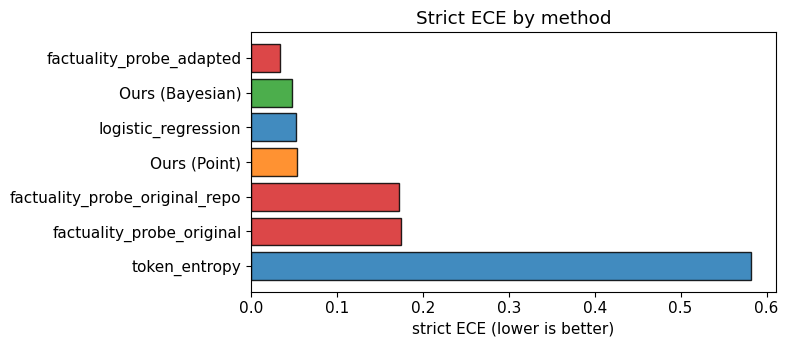

In [5]:
ece_b = get_metric(strict_df, "bayesian", "ECE")
ece_p = get_metric(strict_df, "point", "ECE")
ok = (ece_b < ece_p)
print(f"[STRICT] ECE  Bayesian={ece_b:.4f}  Point={ece_p:.4f}  ->  "
      + ("Bayesian < Point  (hypothesis holds)" if ok else "Bayesian >= Point  (FAILS)"))

if strict_df is not None and "ECE" in strict_df.columns:
    d = strict_df.sort_values("ECE")
    def _col(m):
        ml = m.lower()
        if "bayesian" in ml: return "tab:green"
        if "point" in ml: return "tab:orange"
        if "probe" in ml: return "tab:red"
        return "tab:blue"
    plt.figure(figsize=(8, 3.6))
    plt.barh(d["method"], d["ECE"], color=[_col(m) for m in d["method"]],
             edgecolor="k", alpha=0.85)
    plt.gca().invert_yaxis()
    plt.xlabel("strict ECE (lower is better)"); plt.title("Strict ECE by method")
    plt.tight_layout(); plt.show()

## 5. Comparison vs Han et al. (adapted vs original)

Two variants of the Han probe live in `src/baselines/factuality_probe.py`:

| variant | hidden state | claim handling | is it Han's real method? |
|---|---|---|---|
| **adapted** | cached generation-time | none (sentence last-token) | **no** — re-encoding is skipped |
| **original** | **re-encodes each atomic claim** | per-claim, mean-aggregated | **yes** (their key step) |

The adapted probe is a strong but *simplified* baseline. The fair head-to-head
against the published method uses **original** (run with
`05_baselines.py --run-original`, then re-run `04_evaluate.py`).

In [6]:
bl = (baselines or {}).get("baselines", {})
orig = bl.get("factuality_probe_original")
if orig and not orig.get("skipped"):
    print("factuality_probe_original: PRESENT")
else:
    reason = (orig or {}).get("reason",
              "not run yet -> 05_baselines.py --run-original, then 04_evaluate.py")
    print(f"factuality_probe_original: NOT in tables yet ({reason})")

def _row(label, substr):
    return {"method": label,
            "strict_ECE":   get_metric(strict_df, substr, "ECE"),
            "strict_AUROC": get_metric(strict_df, substr, "AUROC"),
            "ratio_PRR_AUC": get_metric(ratio_df, substr, "PRR_AUC")}

cmp = pd.DataFrame([
    _row("Ours (Bayesian)", "bayesian"),
    _row("Ours (Point)", "point"),
    _row("Han probe - adapted", "adapted"),
    _row("Han probe - original", "original"),
])
display(cmp.round(4))
print("Reminder: an earlier 'we lost to Han' read was only vs the *adapted* probe,")
print("which is not Han's full method. Interpret once 'original' is in the table.")

factuality_probe_original: PRESENT


,method,strict_ECE,strict_AUROC,ratio_PRR_AUC
0,Ours (Bayesian),0.0474,0.7839,0.1394
1,Ours (Point),0.0530,0.7848,0.2483
2,Han probe - adapted,0.0330,0.8113,0.1262
3,Han probe - original,0.1742,0.8487,0.1016


Reminder: an earlier 'we lost to Han' read was only vs the *adapted* probe,
which is not Han's full method. Interpret once 'original' is in the table.


## 6. Known issue — epistemic collapse (`epi_mu ≈ 0`)

`epi_mu = gᵀ Σ̂ g` with `g = mean_ℓ π_ℓ(1-π_ℓ) z_ℓ` is the **variance of the
sentence factuality μ propagated from the posterior covariance Σ̂**. It is the
*reducible* (epistemic) part of uncertainty.

Observed: `epi_mu_mean ≈ 8e-4` (std ≈ 0.03 on a probability). The posterior has
collapsed, so:
- Bayesian and Point predictions are **identical** on MAE/RMSE/Pearson/NLL.
- The rejection curve fails: ranking by `epi_mu` is anti-correlated with
  factuality (it tracks μ̂(1-μ̂), peaking at μ̂≈0.5; in a low-base-rate set the
  lowest-`epi_mu` sentences are confidently non-factual), so the
  *Ours (Bayesian)* PRR curve **falls** instead of rising.

Bayesian vs Point ablation:


,variant,AUROC,Brier,ECE,epi_mu_mean,binomial_NLL
0,Ours (Bayesian),0.783913,0.073367,0.047414,0.000807,1.472786
1,Ours (Point),0.784822,0.073897,0.053003,0.000000,1.472786


epi_mu_mean (Bayesian) = 0.000806615  (variance)  ->  std ~ 0.0284
  => posterior over theta collapsed; Bayesian ~ point estimate.

MC vs linear epistemic (cross-check that it is genuinely tiny, not a linearisation artefact):


,linear_mean,mc_mean,Pearson_r,MAE,num_samples
0,0.000807,0.000677,0.901362,0.000308,100



Prediction-rejection curves (Ours(Bayesian) ranks by epi_mu; everyone else by -mu_hat):


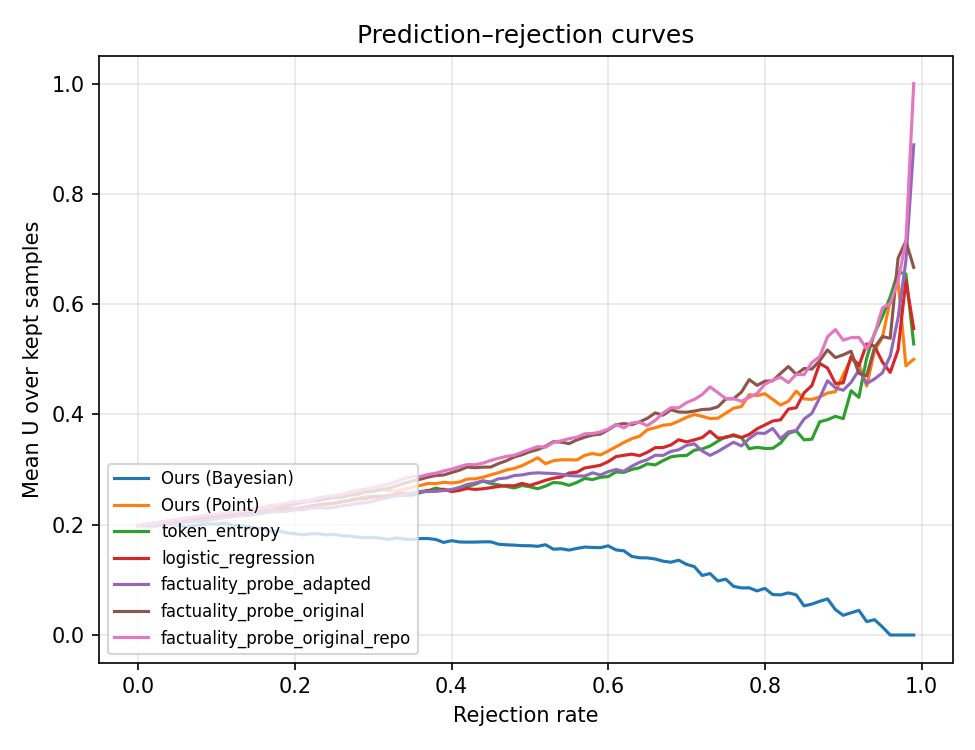

In [7]:
if abl_bp is not None:
    print("Bayesian vs Point ablation:")
    display(abl_bp.round(6))
    sel = abl_bp["variant"].str.contains("Bayesian", case=False)
    if sel.any():
        v = float(abl_bp.loc[sel, "epi_mu_mean"].values[0])
        print(f"epi_mu_mean (Bayesian) = {v:.6g}  (variance)  ->  std ~ {v**0.5:.4f}")
        print("  => posterior over theta collapsed; Bayesian ~ point estimate.")

if abl_mc is not None:
    print("\nMC vs linear epistemic (cross-check that it is genuinely tiny, not a linearisation artefact):")
    display(abl_mc.round(6))

prr_png = results_dir / "prr_curves.png"
if prr_png.exists():
    from IPython.display import Image, display as ipy
    print("\nPrediction-rejection curves "
          "(Ours(Bayesian) ranks by epi_mu; everyone else by -mu_hat):")
    ipy(Image(filename=str(prr_png), width=640))

## 7. Ablations

Binomial vs Bernoulli observation model:


,variant,binomial_NLL,ratio_MAE,strict_ECE,strict_AUROC
0,Binomial,1.4728,0.2181,0.0474,0.7839
1,Bernoulli (m=1),0.3440,0.2379,0.1576,0.8258


Binomial sharply improves strict ECE; count-awareness is the lever.

MC vs linear epistemic agreement:


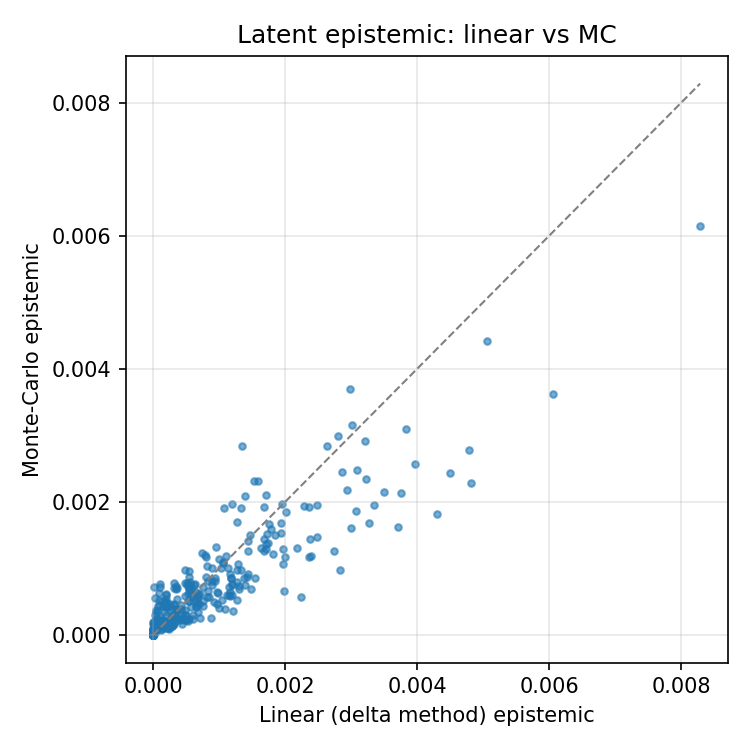

In [8]:
if abl_bb is not None:
    print("Binomial vs Bernoulli observation model:")
    display(abl_bb.round(4))
    print("Binomial sharply improves strict ECE; count-awareness is the lever.")

mc_png = results_dir / "mc_vs_linear.png"
if mc_png.exists():
    from IPython.display import Image, display as ipy
    print("\nMC vs linear epistemic agreement:")
    ipy(Image(filename=str(mc_png), width=480))

## 8. Learned layer weights (α)

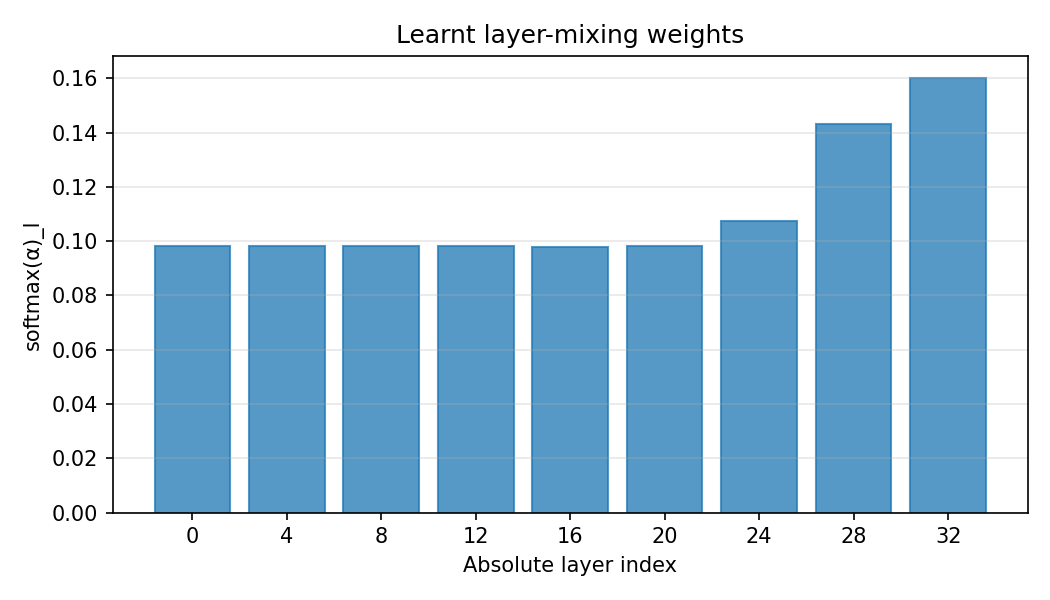

alpha argmax layer: 32 | selected layers: [0, 4, 8, 12, 16, 20, 24, 28, 32]


In [9]:
ap = results_dir / "alpha_distribution.png"
if ap.exists():
    from IPython.display import Image, display as ipy
    ipy(Image(filename=str(ap), width=640))
elif alpha_df is not None:
    display(alpha_df)
if evalsum:
    print("alpha argmax layer:", evalsum.get("alpha_argmax_layer"),
          "| selected layers:", evalsum.get("selected_layers"))

## 9. Summary of findings

In [10]:
print("=" * 70)
print("SUMMARY OF FINDINGS  -  setup 2")
print("=" * 70)

def tag(ok):
    return "OK " if ok else "FAIL"

ece_b = get_metric(strict_df, "bayesian", "ECE")
ece_p = get_metric(strict_df, "point", "ECE")
ece_adapt = get_metric(strict_df, "adapted", "ECE")
ece_orig = get_metric(strict_df, "original", "ECE")
prr_b = get_metric(ratio_df, "bayesian", "PRR_AUC")
prr_p = get_metric(ratio_df, "point", "PRR_AUC")
mc_r = float(abl_mc["Pearson_r"].values[0]) if (abl_mc is not None and "Pearson_r" in abl_mc.columns) else float("nan")
epi = float("nan")
if abl_bp is not None:
    sel = abl_bp["variant"].str.contains("Bayesian", case=False)
    if sel.any():
        epi = float(abl_bp.loc[sel, "epi_mu_mean"].values[0])

print(f"[{tag(ece_b < ece_p)}] Core: Bayesian ECE < Point ECE          ({ece_b:.4f} < {ece_p:.4f})")
print(f"[{tag(ece_b < ece_adapt)}] vs adapted Han-probe ECE               ({ece_b:.4f} vs {ece_adapt:.4f})")
if np.isfinite(ece_orig):
    print(f"[{tag(ece_b < ece_orig)}] vs ORIGINAL Han-probe ECE (faithful)   ({ece_b:.4f} vs {ece_orig:.4f})")
else:
    print("[ -- ] vs ORIGINAL Han-probe: run --run-original + re-evaluate to fill in")
print(f"[{tag(mc_r > 0.9)}] MC vs linear epistemic corr > 0.9       (r={mc_r:.3f})")
print(f"[!!!] Epistemic collapse: epi_mu_mean ~ {epi:.4g}  (Bayesian ~ point)")
print(f"[!!!] PRR: Bayesian ({prr_b:.3f}) < Point ({prr_p:.3f}) -> epistemic not a usable rejection signal")
print()
print("Open issue for next session: epistemic uncertainty has collapsed.")
print("Root-cause candidates: Laplace Sigma_hat scale (prior_sigma / Fisher precision)")
print("and the pi(1-pi) weighting that makes epi_mu a function of mu_hat.")

SUMMARY OF FINDINGS  -  setup 2
[OK ] Core: Bayesian ECE < Point ECE          (0.0474 < 0.0530)
[FAIL] vs adapted Han-probe ECE               (0.0474 vs 0.0330)
[OK ] vs ORIGINAL Han-probe ECE (faithful)   (0.0474 vs 0.1742)
[OK ] MC vs linear epistemic corr > 0.9       (r=0.901)
[!!!] Epistemic collapse: epi_mu_mean ~ 0.0008066  (Bayesian ~ point)
[!!!] PRR: Bayesian (0.139) < Point (0.248) -> epistemic not a usable rejection signal

Open issue for next session: epistemic uncertainty has collapsed.
Root-cause candidates: Laplace Sigma_hat scale (prior_sigma / Fisher precision)
and the pi(1-pi) weighting that makes epi_mu a function of mu_hat.
